In [16]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import binom_tost_reject_interval


def fit_func(freq, tau, phi_0):
    omega = 2*np.pi*freq
    phi = np.arctan(omega*tau)
    return phi + phi_0

def temperature_dependence(T, t0, a):
    return t0*np.exp(a*(T-298))

def reduced_chi_squared_calc(model, model_params, xdata, ydata, yerror):
    dof = len(xdata)-len(model_params)
    theoretical = model(xdata,*model_params)
    chi2 = np.sum((theoretical - ydata)**2/(yerror**2))
    rchi2 = chi2/dof
    return chi2, rchi2

plt.rcParams.update({
    "font.size": 14,        # default text size
    "axes.titlesize": 16,   # title size
    "axes.labelsize": 15,   # axis labels
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.rcParams.update({
    "font.family": "Times New Roman",  # Use Times New Roman for all text
    "mathtext.fontset": "custom",      # Use custom font for math
    "mathtext.rm": "Times New Roman",  # Roman font in math
    "mathtext.it": "Times New Roman:italic",  # Italic font in math
    "mathtext.bf": "Times New Roman:bold",    # Bold font in math
    "text.usetex": False
})

csv = "Amplitude_Data.csv"
df_amplitude = pd.read_csv(csv)

temp_amp = df_amplitude["Temperatures"]
life_amp = df_amplitude["Lifetimes"]
life_err_amp = df_amplitude["Errors"]
pop_amp = [df_amplitude["t0"][0], df_amplitude["a"][1]]
err_amp = [df_amplitude["t0_err"][0], df_amplitude["a_err"][0]]

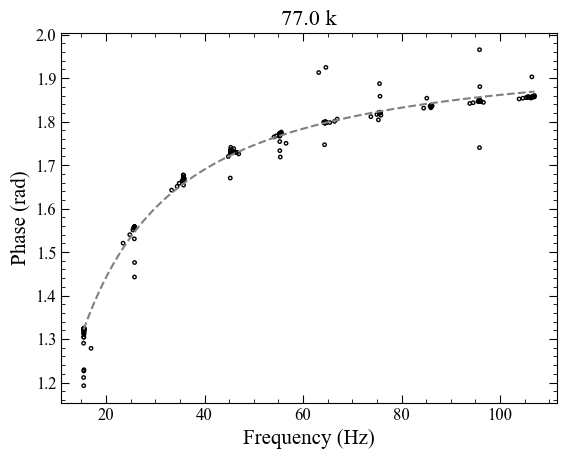

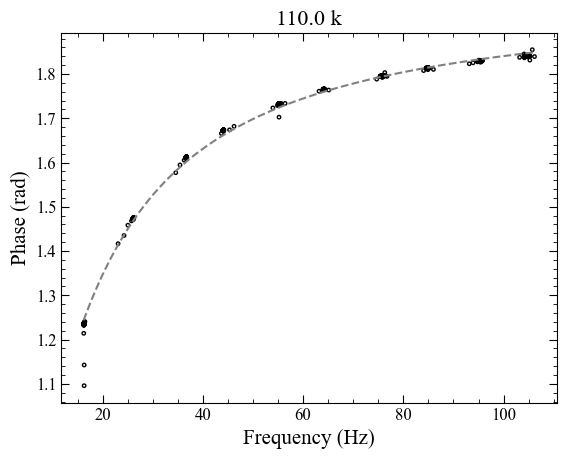

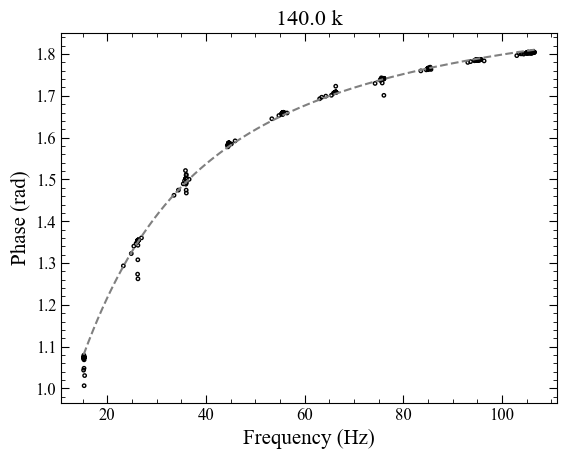

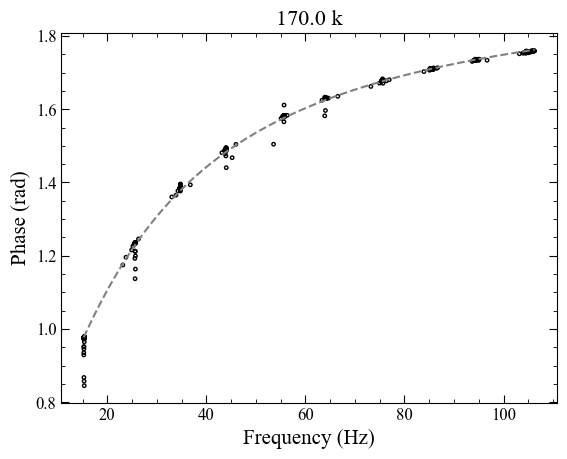

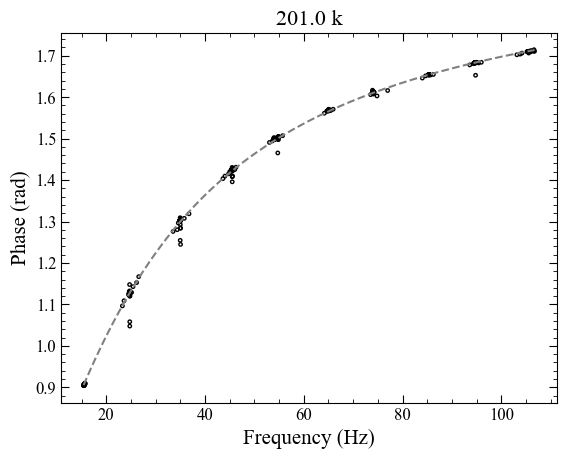

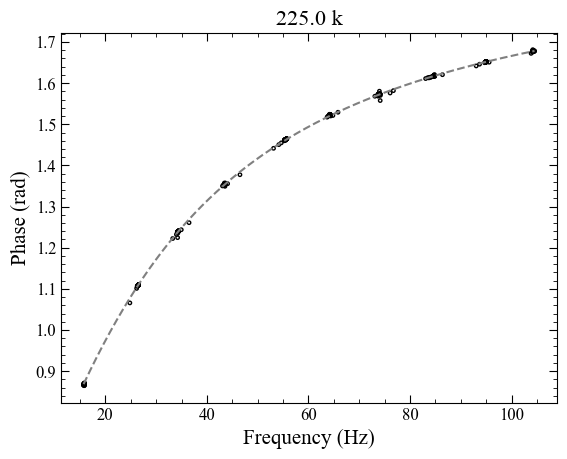

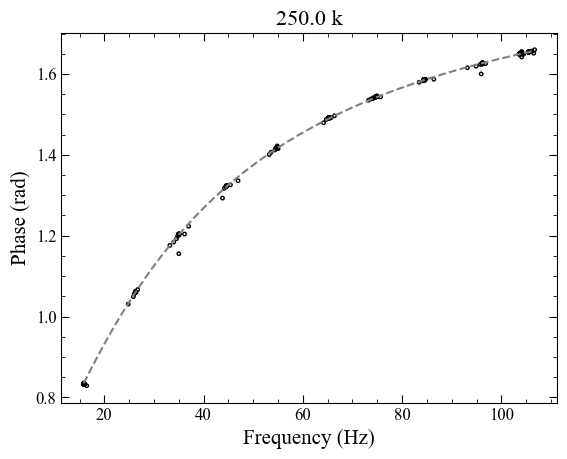

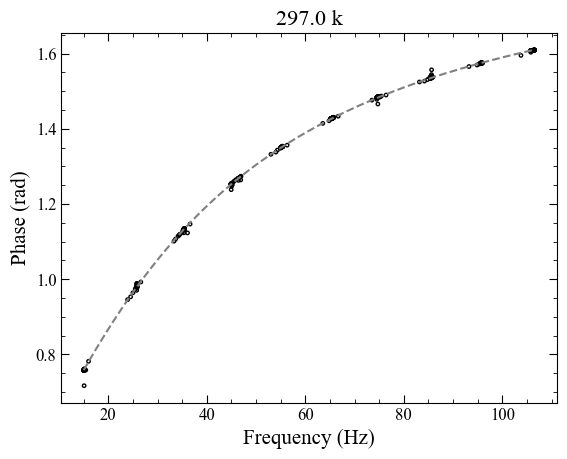

[ 0.00381649 -0.00483962]


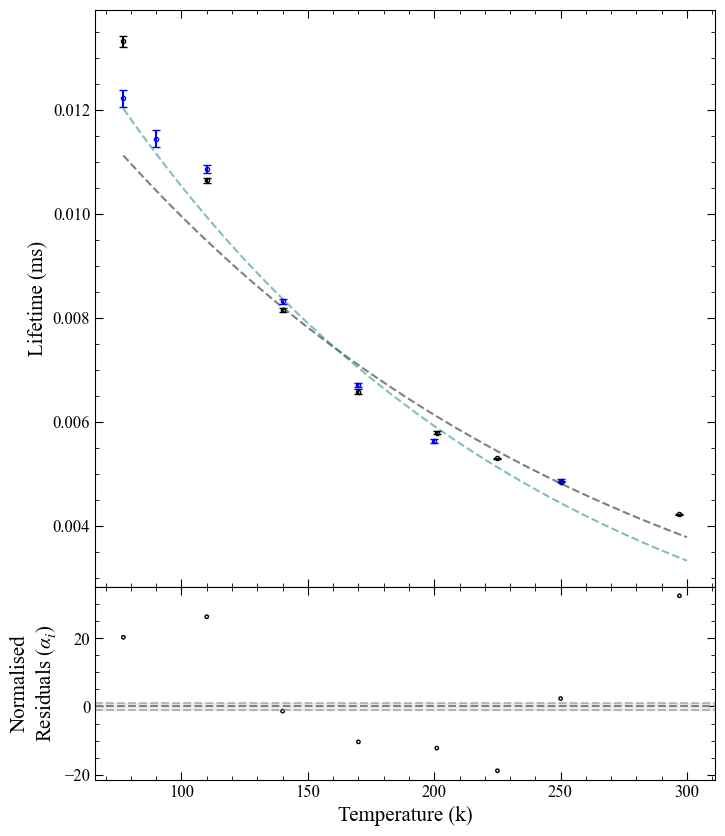

Phase Method lifetime: 0.00382 pm 0.00001
Amplitude Method lifetime: 0.00337 pm 0.00002


In [17]:
file = "Freq_Data.xlsx"

column_names = [
    ["freq_77", "phase_77"],
    ["freq_110", "phase_110"],
    ["freq_140", "phase_140"],
    ["freq_170", "phase_170"],
    ["freq_201", "phase_201"],
    ["freq_225", "phase_225"],
    ["freq_250", "phase_250"],
    ["freq_297", "phase_297"],
]

df = pd.read_excel(file)

points = [15, 25, 35, 45, 55, 65, 75, 85, 95, 105]
pm = 2

lifetimes = []
lifetime_errors = []
temperatures = []

phase_data = {}

for col in column_names:
    temp = float(col[0].split("_")[1])

    x_raw = df[col[0]]
    y_raw = df[col[1]]
    y_rad = y_raw * np.pi / 180

    mask = np.zeros_like(x_raw, dtype=bool)

    for p in points:
        mask |= (x_raw >= p - pm) & (x_raw <= p + pm)

    x_sliced = x_raw[mask]
    y_sliced = y_rad[mask]
    y_sliced = np.abs(y_sliced)

    p0 = [0.004,0.4]

    pop, cov = curve_fit(fit_func,
                         x_sliced,
                         y_sliced,
                         p0 = p0,
                         maxfev = 10000)

    x_fit = np.linspace(x_sliced.min(), x_sliced.max(), 10000)

    plt.figure(1)
    plt.scatter(x_sliced, y_sliced,
                marker = 'o', facecolor = 'none',color = "black", s = 6)
    plt.plot(x_fit, fit_func(x_fit, *pop),
             color = "grey", linestyle = "--")

    plt.minorticks_on()
    plt.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    plt.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

    plt.title(f"{temp} k")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Phase (rad)")
    plt.show()

    temperatures.append(temp)
    lifetimes.append(pop[0])
    lifetime_errors.append(np.sqrt(np.diag(cov)[0]))

    phase_data[temp] = {
    "x": x_sliced,
    "y": y_sliced,
    "fit_params": pop
}




temperatures = np.array(temperatures)
lifetimes = np.array(lifetimes)
lifetime_errors = np.array(lifetime_errors)

T_fit = np.linspace(temperatures.min(), 300, 10000)

p0 = [0.003, #roomtemp lifetime
      -0.01 #a
      ] #offset

p0_bounds = [
    [0.002, -np.inf], #lower
    [0.004, 0] #upper
]

pop, cov = curve_fit(temperature_dependence,
                     temperatures,
                     lifetimes,
                     sigma = lifetime_errors,
                     absolute_sigma = True,
                     p0 = p0,
                     bounds = p0_bounds,
                     maxfev = 10000)
print(pop)

residuals = (lifetimes-temperature_dependence(temperatures, *pop))/lifetime_errors


fig = plt.figure(figsize = (8,10))

gs = fig.add_gridspec(
    2, 1,
    hspace = 0,
    height_ratios = [3,1],
)
ax_main = fig.add_subplot(gs[0])
ax_res = fig.add_subplot(gs[1], sharex = ax_main)

###########
# main plot
###########

ax_main.set_ylabel("Lifetime (ms)")

ax_main.errorbar(temperatures, lifetimes, yerr= lifetime_errors,
            marker = 'o', markerfacecolor = 'none',color = "black", markersize = 3, capsize = 3, linestyle = "none")
ax_main.plot(T_fit, temperature_dependence(T_fit, *pop),
          color = "grey", linestyle = "--")

ax_main.errorbar(temp_amp, life_amp, yerr= life_err_amp,
            marker = 'o', markerfacecolor = 'none',color = "blue", markersize = 3, capsize = 3, linestyle = "none")
ax_main.plot(T_fit, temperature_dependence(T_fit, *pop_amp),
          color = "teal", linestyle = "--", alpha = 0.5)

###############
# residual plot
###############


ax_res.set_xlabel("Temperature (k)")
ax_res.set_ylabel("Normalised\nResiduals ($\\alpha_i$)")

ax_res.scatter(temperatures, residuals,
            marker = 'o', facecolor = 'none',color = "black", s = 6)

ax_res.axhspan(-1,1, color = "grey", alpha = 0.12)
ax_res.axhline(-1, color = "grey", linestyle = "--",alpha = 0.5)
ax_res.axhline(1, color = "grey", linestyle = "--", alpha = 0.5)
ax_res.axhline(0, color = "grey", linestyle = "--")

for ax in [ax_main, ax_res]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

plt.show()

print(f"Phase Method lifetime: {pop[0]:.5f} pm {np.sqrt(np.diag(cov)[0]):.5f}")
print(f"Amplitude Method lifetime: {pop_amp[0]:.5f} pm {err_amp[0]:.5f}")

# Phase Plot

In [18]:
# prep
red_cb = "#e41a1c"
blue_cb = "#377eb8"
purple_cb = "#984ea3"

laptop_savepath_phase = r"C:\Users\sebas\Documents\Durham Work\Year 3\Advanced Lab\Report Figures\phase_plot.png"
pc_savepath_phase = r"C:\Users\User\Documents\Durham Work\Year 3\Advanced_Lab\Report\Figures\phase_plot.png"

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as colors
import matplotlib.cm as cm

cmap = LinearSegmentedColormap.from_list(
    "red_blue_gradient",
    [blue_cb,red_cb],
    N = 256
)

temps = np.array(list(phase_data.keys()))
norm = colors.Normalize(vmin=temps.min(), vmax=temps.max())

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\sebas\\Documents\\Durham Work\\Year 3\\Advanced Lab\\Report Figures\\phase_plot.png'

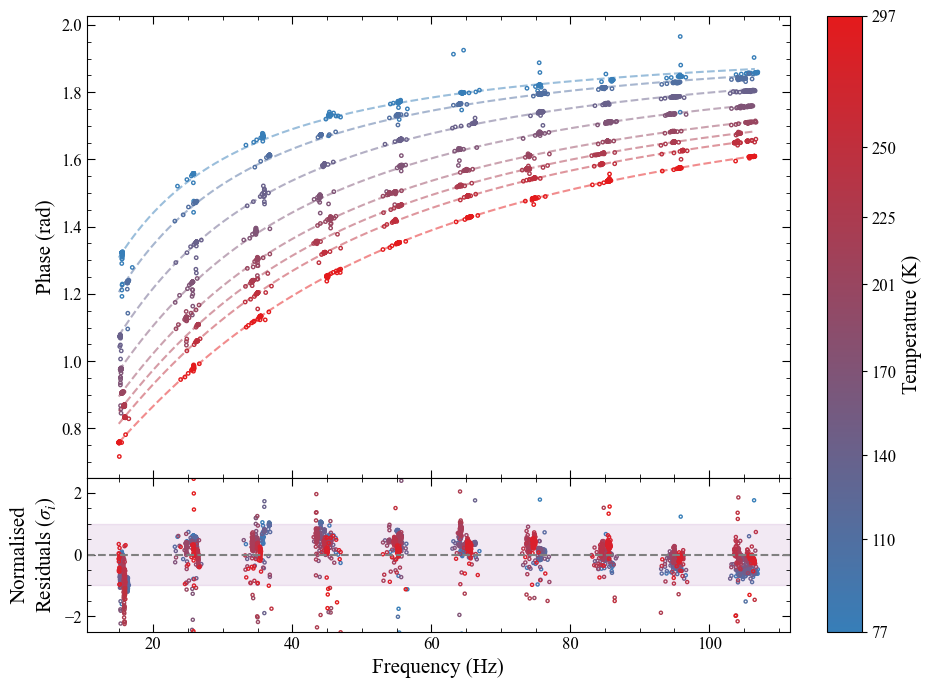

In [19]:
fig = plt.figure(figsize = (10,8))

gs = fig.add_gridspec(
    2, 2,
    hspace = 0,
    wspace = 0.1,
    height_ratios = [3,1],
    width_ratios = [20,1],
)


ax_main = fig.add_subplot(gs[0,0])
ax_res = fig.add_subplot(gs[1,0], sharex = ax_main)
ax_res.set_ylim([-2.5, 2.5])

ax_cb = fig.add_subplot(gs[:,1])

ax_main.set_ylabel("Phase (rad)")
ax_res.set_ylabel("Normalised\nResiduals ($\\sigma_i$)")
ax_res.set_xlabel("Frequency (Hz)")

###########
# Main Plot
###########

for (temp, data) in phase_data.items():
    pop_phase = phase_data[temp]["fit_params"]

    colour = cmap(norm(temp))

    ax_main.scatter(data["x"], data["y"],
        s=6, facecolor='none', edgecolor=colour
    )

    ax_main.plot(x_fit, fit_func(x_fit, *pop_phase),
                 linestyle = "--", color = colour, alpha = 0.5)


###########
# Residuals
###########
for (temp, data) in phase_data.items():
    pop_phase = phase_data[temp]["fit_params"]
    residual = (data["y"]-fit_func(data["x"], *pop_phase))
    residual /= np.std(residual)
    colour = cmap(norm(temp))
    ax_res.scatter(data["x"], residual,
                   color = colour, marker = "o", facecolor = "none", s = 5)

ax_res.axhspan(-1,1, color = purple_cb, alpha = 0.12)
ax_res.axhline(0, color = "grey", linestyle = "--")



###########
# Color Bar
###########

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=ax_cb,
    orientation="vertical"
)

cbar.set_label("Temperature (K)")
cbar.set_ticks(sorted(phase_data.keys()))



#########
# Styling
#########

for ax in [ax_main, ax_res]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True, bottom=True, left = True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True, bottom=True, left = True)

plt.savefig(laptop_savepath_phase,
            dpi = 150,
            bbox_inches = 'tight')
plt.show()

In [20]:
chi2_amp, rchi2_amp = reduced_chi_squared_calc(temperature_dependence,
                                               model_params= pop_amp,
                                               xdata = temp_amp,
                                               ydata = life_amp,
                                               yerror = life_err_amp,
                                               )

chi2_pha, rchi2_pha = reduced_chi_squared_calc(temperature_dependence,
                                               model_params= pop_phase,
                                               xdata = temperatures,
                                               ydata = lifetimes,
                                               yerror = lifetime_errors,
                                               )

print(rchi2_amp)
print(rchi2_pha)

112.43011619131622
147371.71885311525


# Combined Plot

In [ ]:
#prep

laptop_savepath_PhaseAmp = r"C:\Users\sebas\Documents\Durham Work\Year 3\Advanced Lab\Report Figures\Phase_Amp_plot.png"
pc_savepath_PhaseAmp = r"C:\Users\User\Documents\Durham Work\Year 3\Advanced_Lab\Report\Figures\Phase_Amp_plot.png"

residual_amp = (life_amp-temperature_dependence(temp_amp, *pop_amp))/life_err_amp

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

residual_band= Patch(
    facecolor= purple_cb,
    alpha=0.12,
    label=r"$1\sigma$ Residuals"
)

Amp_Phase_legend = [
    Line2D([0], [0],
           color= blue_cb,
           marker = "o",
           linestyle='--',
           markerfacecolor="none", markersize=5, linewidth=1.5,
           label=r"Amplitude Data"),

    Line2D([0], [0],
           color= red_cb,
           marker = "o",
           linestyle='--',
           markerfacecolor="none", markersize=5, linewidth=1.5,
           label=r"Phase Data"),

    residual_band
]
t_298_phase = pop[0]
t_298_phase_err = np.sqrt(np.diag(cov)[0])
t_298_amp = pop_amp[0]
t_298_amp_err = err_amp[0]
scale_factor = 1000

t_298_phase = t_298_phase*scale_factor
t_298_amp = t_298_amp*scale_factor
t_298_phase_err = t_298_phase_err*scale_factor
t_298_amp_err = t_298_amp_err*scale_factor

In [ ]:
fig = plt.figure(figsize = (10,8))

gs = fig.add_gridspec(
    2,1,
    hspace = 0,
    height_ratios = [3,1]
)

ax_main = fig.add_subplot(gs[0])
ax_res = fig.add_subplot(gs[1], sharex = ax_main)


###########
# Main Plot
###########

ax_main.set_ylabel("Lifetime (ms)")


#phase
ax_main.errorbar(temperatures, lifetimes*scale_factor, yerr= lifetime_errors*scale_factor,
            marker = 'o', markerfacecolor = 'none',color = red_cb, markersize = 3, capsize = 3, linestyle = "none")
ax_main.plot(T_fit, temperature_dependence(T_fit, *pop)*scale_factor,
          color = red_cb , linestyle = "--", alpha = 0.5)


#amplitude
ax_main.errorbar(temp_amp, life_amp*scale_factor, yerr= life_err_amp*scale_factor,
            marker = 'o', markerfacecolor = 'none',color = blue_cb, markersize = 3, capsize = 3, linestyle = "none")
ax_main.plot(T_fit, temperature_dependence(T_fit, *pop_amp)*scale_factor,
          color = blue_cb, linestyle = "--", alpha = 0.5)

ax_main.legend(
    handles = Amp_Phase_legend,
    loc = "upper left",
    bbox_to_anchor = (0.75,0.95 ),
    frameon = False
)

ax_main.text(
    0.1, 0.3,
    rf"$\tau_{{0,\mathrm{{theory}}}} = [3,4]\,\mathrm{{ms}}$",
    transform=ax_main.transAxes,
    fontsize=12,
    verticalalignment='top'
)

ax_main.text(
    0.1, 0.25,
    rf"$\tau_{{0,\mathrm{{amplitude}}}} = {t_298_amp:.3f}\,±\,{t_298_amp_err:.3f}\,\mathrm{{ms}}$",
    transform=ax_main.transAxes,
    fontsize=12,
    verticalalignment='top'
)

ax_main.text(
    0.1, 0.20,
    rf"$\tau_{{0,\mathrm{{phase}}}} = {t_298_phase:.3f}\,±\,{t_298_phase_err:.3f}\,\mathrm{{ms}}$",
    transform=ax_main.transAxes,
    fontsize=12,
    verticalalignment='top'
)

###############
# residual plot
###############


ax_res.set_xlabel("Temperature (k)")
ax_res.set_ylabel("Normalised\nResiduals ($\\alpha_i$)")

ax_res.scatter(temperatures, residuals,
            marker = 'o', facecolor = 'none',color = red_cb, s = 6)

ax_res.scatter(temp_amp, residual_amp,
               marker = "o", facecolor = 'none',color = blue_cb, s = 6)


ax_res.axhspan(-1,1, color = purple_cb, alpha = 0.12)
ax_res.axhline(0, color = "grey", linestyle = "--")


#########
# Styling
#########

for ax in [ax_main, ax_res]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True, bottom=True, left = True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True, bottom=True, left = True)

plt.savefig(laptop_savepath_PhaseAmp,
            dpi = 150,
            bbox_inches = 'tight')
plt.show()

# 2 sigma outliers

In [ ]:

# 2 Sigma Outlier Detection (Phase)
for temp, data in phase_data.items():

    x = data["x"]
    y = data["y"]

    inlier_mask = np.ones_like(y, dtype=bool)

    for p in points:
        mask = (x >= p - pm) & (x <= p + pm)

        if np.sum(mask) < 2:
            continue

        y_bin = y[mask]

        mean = np.mean(y_bin)
        std = np.std(y_bin)

        if std == 0:
            continue

        outliers_here = np.abs(y_bin - mean) > 2 * std

        idx = np.where(mask)[0]
        inlier_mask[idx[outliers_here]] = False

    # Store masks
    phase_data[temp]["inlier_mask_sigma"] = inlier_mask
    phase_data[temp]["outlier_mask_sigma"] = ~inlier_mask

# Refit using 2σ cleaned data
for temp, data in phase_data.items():
    x = data["x"]
    y = data["y"]

    inliers = data["inlier_mask_sigma"]

    x_clean = x[inliers]
    y_clean = y[inliers]

    pop_clean, cov_clean = curve_fit(
        fit_func,
        x_clean,
        y_clean,
        p0=[0.004, 0.4],
        maxfev=10000
    )

    phase_data[temp]["fit_params_clean"] = pop_clean

from matplotlib.lines import Line2D

outlier_legend = [
    Line2D([0], [0],
           color="black",
           marker="o",
           linestyle='none',
           markerfacecolor="none",
           markersize=5,
           label="Inliers"),

    Line2D([0], [0],
           color="black",
           marker="x",
           linestyle='none',
           markersize=5,
           label=r"$2\sigma$ outliers"),
]

ax_main.legend(handles=outlier_legend, loc="upper right", frameon=False)

In [ ]:
fig = plt.figure(figsize = (10,8))

gs = fig.add_gridspec(
    2, 2,
    hspace = 0,
    wspace = 0.1,
    height_ratios = [3,1],
    width_ratios = [20,1],
)


ax_main = fig.add_subplot(gs[0,0])
ax_res = fig.add_subplot(gs[1,0], sharex = ax_main)
ax_res.set_ylim([-2.5, 2.5])

ax_cb = fig.add_subplot(gs[:,1])

ax_main.set_ylabel("Phase (rad)")
ax_res.set_ylabel("Normalised\nResiduals ($\\sigma_i$)")
ax_res.set_xlabel("Frequency (Hz)")

###########
# Main Plot (2σ cleaned)
###########

for (temp, data) in phase_data.items():
    pop_phase = data.get("fit_params_clean", data["fit_params"])
    colour = cmap(norm(temp))

    inliers = data.get("inlier_mask_sigma", np.ones_like(data["x"], dtype=bool))
    outliers = ~inliers

    # Inliers → circles
    ax_main.scatter(
        data["x"][inliers],
        data["y"][inliers],
        s=6,
        facecolor='none',
        edgecolor=colour,
        marker='o'
    )

    # Outliers → crosses
    ax_main.scatter(
        data["x"][outliers],
        data["y"][outliers],
        s=10,
        color=colour,
        marker='x',
        alpha=0.8
    )

    # Fit (cleaned)
    ax_main.plot(
        x_fit,
        fit_func(x_fit, *pop_phase),
        linestyle="--",
        color=colour,
        alpha=0.5
    )

ax_main.legend(
    handles = outlier_legend,
    loc="upper right",
    frameon=False,
    bbox_to_anchor=(1, 0.2),
)


###########
# Residuals (2σ cleaned)
###########

for (temp, data) in phase_data.items():
    pop_phase = data.get("fit_params_clean", data["fit_params"])
    colour = cmap(norm(temp))

    residual = (data["y"] - fit_func(data["x"], *pop_phase))
    residual /= np.std(residual)

    inliers = data.get("inlier_mask_sigma", np.ones_like(data["x"], dtype=bool))
    outliers = ~inliers

    # Inliers
    ax_res.scatter(
        data["x"][inliers],
        residual[inliers],
        color=colour,
        marker="o",
        facecolor="none",
        s=5
    )

    # Outliers
    ax_res.scatter(
        data["x"][outliers],
        residual[outliers],
        color=colour,
        marker="x",
        s=10
    )

ax_res.axhspan(-1,1, color = purple_cb, alpha = 0.12)
ax_res.axhline(0, color = "grey", linestyle = "--")



###########
# Color Bar
###########

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=ax_cb,
    orientation="vertical"
)

cbar.set_label("Temperature (K)")
cbar.set_ticks(sorted(phase_data.keys()))



#########
# Styling
#########

for ax in [ax_main, ax_res]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True, bottom=True, left = True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True, bottom=True, left = True)

plt.savefig(laptop_savepath_phase,
            dpi = 150,
            bbox_inches = 'tight')
plt.show()

# Cleaned Lifetimes

In [ ]:
# Cleaned Phase Lifetimes (2σ)
lifetimes_phase_clean = []
lifetime_errors_phase_clean = []
temperatures_phase_clean = []

for temp, data in phase_data.items():
    pop_clean = data["fit_params_clean"]

    # Extract τ and its error
    tau = pop_clean[0]

    # You need covariance too → recompute properly:
    x = data["x"]
    y = data["y"]
    inliers = data["inlier_mask_sigma"]

    pop, cov = curve_fit(
        fit_func,
        x[inliers],
        y[inliers],
        p0=[0.004, 0.4],
        maxfev=10000
    )

    tau_err = np.sqrt(np.diag(cov)[0])

    temperatures_phase_clean.append(temp)
    lifetimes_phase_clean.append(tau)
    lifetime_errors_phase_clean.append(tau_err)

In [ ]:
# Load cleaned amplitude data (2σ)
csv_amp_clean = "lifetimes_2sigma_cleaned.csv"

df_amp_clean = pd.read_csv(csv_amp_clean)

temperatures_amp_clean = df_amp_clean["Temperature_K"].values
lifetimes_amp_clean = df_amp_clean["Lifetime_s"].values
lifetime_errors_amp_clean = df_amp_clean["Lifetime_error_s"].values

pop_amp_clean, cov_amp_clean = curve_fit(
    temperature_dependence,
    temperatures_amp_clean,
    lifetimes_amp_clean,
    sigma=lifetime_errors_amp_clean,
    absolute_sigma=True,
    p0=[0.003, -0.01],
    bounds=([0, -np.inf], [np.inf, 0]),
    maxfev=10000
)

In [ ]:
# Phase
temperatures_phase_clean = np.array(temperatures_phase_clean)
lifetimes_phase_clean = np.array(lifetimes_phase_clean)
lifetime_errors_phase_clean = np.array(lifetime_errors_phase_clean)

order = np.argsort(temperatures_phase_clean)

temperatures_phase_clean = temperatures_phase_clean[order]
lifetimes_phase_clean = lifetimes_phase_clean[order]
lifetime_errors_phase_clean = lifetime_errors_phase_clean[order]


# Amplitude
temperatures_amp_clean = np.array(temperatures_amp_clean)
lifetimes_amp_clean = np.array(lifetimes_amp_clean)
lifetime_errors_amp_clean = np.array(lifetime_errors_amp_clean)

order = np.argsort(temperatures_amp_clean)

temperatures_amp_clean = temperatures_amp_clean[order]
lifetimes_amp_clean = lifetimes_amp_clean[order]
lifetime_errors_amp_clean = lifetime_errors_amp_clean[order]

In [ ]:
pop_phase_clean, cov_phase_clean = curve_fit(
    temperature_dependence,
    temperatures_phase_clean,
    lifetimes_phase_clean,
    sigma=lifetime_errors_phase_clean,
    absolute_sigma=True,
    p0=[0.003, -0.01],
    bounds=([0, -np.inf], [np.inf, 0]),
    maxfev=10000
)

In [ ]:
print("=== ROOM TEMP LIFETIMES ===")

print(f"Phase (raw):    {pop[0]:.5f} ± {np.sqrt(np.diag(cov)[0]):.5f}")
print(f"Phase (clean):  {pop_phase_clean[0]:.5f} ± {np.sqrt(np.diag(cov_phase_clean)[0]):.5f}")

print()

print(f"Amp (raw):      {pop_amp[0]:.5f} ± {err_amp[0]:.5f}")
print(f"Amp (clean):    {pop_amp_clean[0]:.5f} ± {np.sqrt(np.diag(cov_amp_clean)[0]):.5f}")